In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import plotly.express as px
from matplotlib.colors import LogNorm
from plotly.subplots import make_subplots
import numpy as np

In [30]:
mapping = {
    'Congo (Kinshasa)': 'Democratic Republic of the Congo',
    'Congo (Brazzaville)': 'Republic of the Congo',
    'US': 'United States of America',
    'USA': 'United States of America',
    'United States': 'United States of America',
    'Tanzania': 'United Republic of Tanzania'
}

In [11]:
dfUsersRatings = pd.read_csv("../data/cleaned/users_ratings.csv", nrows=2000000)
dfUsersRatings = dfUsersRatings.sample(500_000, random_state=42)
dfUsersRatings

,username,anime_id,status,score,num_watched_episodes
1828401,Frabosco,32729,completed,9,13
1200071,Caboose,1065,plan_to_watch,0,0
194849,ThomasioDeWeeb,31240,plan_to_watch,0,0
1629054,Rivido,37349,completed,9,12
191144,armandomora,35459,completed,7,1
...,...,...,...,...,...
485652,Forehead-chan,121,on_hold,0,15
1590998,Tiagolbs,38830,plan_to_watch,0,0
1579668,RiverboatRam,813,completed,7,291
72585,ThomasBull,55877,plan_to_watch,0,0


#### Let's analyze the ratings data
1. Users mostly rate shows they finish, this explains why the bar chart is skewed upward:
If someone hates a show, they drop it → no rating
If they finish it, they probably liked it → rating 7–8
So the bar chart is not a neutral distribution of quality.
2. User ratings ≠ Anime scores.
3. The pie chart explains the bar chart because most users complete shows, the ratings cluster around:
- 7–8 (liked it)
- 8–9 (really liked it)

Very few ratings come from dropped shows → very few low scores.

In [ ]:
pieChart = px.pie(dfUsersRatings, names="status", title="Anime Status")

dfScores = (
    dfUsersRatings.groupby("score")
    .size()
    .reset_index(name="num_ratings")
)
barChart = px.bar(dfScores, x="score", y="num_ratings")
barChart.update_traces(x=dfScores["score"], y=dfScores["num_ratings"])

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}]]
)

# Add pie chart
for trace in pieChart.data:
    fig.add_trace(trace, row=1, col=2)

# Add bar chart
for trace in barChart.data:
    fig.add_trace(trace, row=1, col=1)

fig.update_layout(title="Status Pie Chart + Score Bar Chart", title_x=0.5)
fig.update_xaxes(range=[1, 10], row=1, col=1)
fig.update_yaxes(range=[0, 80000], row=1, col=1)
fig.show()

dfScores = None

##### Here we can see that the number of episodes watched have an impact on the score given by the user. It makes sense because if a user don't like an anime is more prone to drop it

In [ ]:
px.scatter(dfUsersRatings, y="num_watched_episodes", x="score", opacity=0.3)

#### Anime Score per Number of episodes watched:
This horizontal bar chart reveals a positive relationship between how many episodes a user watches and the score they eventually give.
This chart reflects a very typical pattern in user‑rating datasets:
- People rarely give a high score to a show they barely watched.
- People rarely watch many episodes of a show they dislike.
- High scores are strongly associated with completion or near‑completion.

Low scores often come from users who drop early.
In simple terms, the more episodes someone watches, the higher the score they tend to assign.

In [5]:
dfAgg = dfUsersRatings.groupby("score")["num_watched_episodes"].mean().reset_index()

fig = px.bar(
    dfAgg,
    x="num_watched_episodes",
    y="score",
    orientation="h",
    labels={
        "score": "Anime Score",
        "num_watched_episodes": "Mean of n° episodes watched"
    }
)
fig.update_yaxes(range=[1, 10])
fig.show()
dfAgg = None

##### Here we can see a high number of anime dropped on lower scores

<Axes: xlabel='status', ylabel='score'>

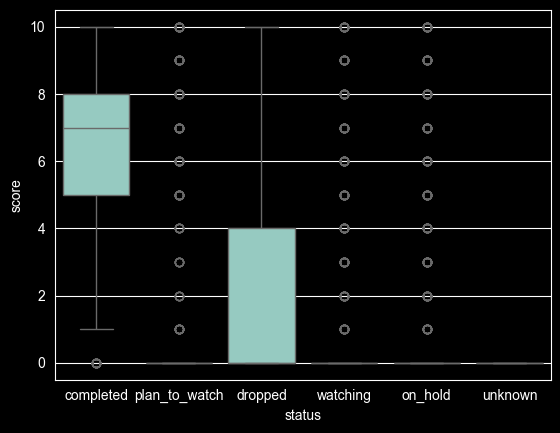

In [40]:
sns.boxplot(data=dfUsersRatings, x="status", y="score")

In [41]:
dfUsersRatings = None

In [42]:
dfUsersFavs = pd.read_csv("../data/cleaned/users_favs.csv")
dfUsersFavs

,Unnamed: 0,username,fav_type,id
0,0,ishikawas,anime,45649
1,1,ishikawas,anime,38680
2,2,ishikawas,anime,795
3,3,ishikawas,anime,37510
4,4,ishikawas,anime,820
...,...,...,...,...
4178738,4178742,vincent0607,character,497
4178739,4178743,vincent0607,character,118739
4178740,4178744,vincent0607,character,188177
4178741,4178745,vincent0607,character,141354


In [43]:
dfAnime = pd.read_csv("../data/cleaned/anime.csv", usecols=["mal_id", "title", "score", "popularity"])
#dfAnime

In [44]:
fav_anime = dfUsersFavs[dfUsersFavs["fav_type"] == "anime"]
fav_anime = fav_anime.drop(columns=["fav_type"])
#fav_anime

In [45]:
dfUsersFavs = None

In [46]:
dfAnime = dfAnime.merge(fav_anime, left_on="mal_id", right_on="id")
fav_anime = None
#dfAnime

In [47]:
top20 = (
    dfAnime.groupby(["id", "title", "score"])
          .size()
          .reset_index(name="num_favs")
          .sort_values("num_favs", ascending=False)
          .head(20)
)
top20

,id,title,score,num_favs
3677,11061,Hunter x Hunter (2011),9.03,31558
3345,9253,Steins;Gate,9.07,30757
2655,5114,Fullmetal Alchemist: Brotherhood,9.10,27886
11,21,One Piece,8.73,27337
4156,16498,Shingeki no Kyojin,8.56,19480
1155,1535,Death Note,8.62,18896
20,30,Shinseiki Evangelion,8.36,15591
8567,52991,Sousou no Frieren,9.29,15409
1183,1575,Code Geass: Hangyaku no Lelouch,8.71,13621
4992,28851,Koe no Katachi,8.93,13574


##### It appears that the number of favorites does not have a huge impact on the score of the anime. Even anime that have a low number of favorites bring an high score. This behavior could be explained by the fact that a user will not put an anime in the favorites if it wasn't good.

In [48]:
dfFav = (
    dfAnime.groupby(["id", "title", "score"])
          .size()
          .reset_index(name="num_favs")
          .sort_values("num_favs", ascending=False)
)

fig = px.scatter(
    dfFav,
    x="num_favs",
    y="score",
    hover_name="title",
    size="num_favs",
    opacity=0.7
)
fig.update_traces(textposition="top center")
fig.show()

In [49]:
dfTemp = dfAnime.groupby("mal_id", as_index=False).first()
dfFav = dfFav.merge(dfTemp[["mal_id", "popularity"]], left_on="id", right_on="mal_id")
dfTemp = None
dfFav = dfFav.drop(columns=["mal_id"])
#dfFav

##### Maybe it was expected to see the popularity of an anime to grow with the score, but as we can see it does not. Actually there is a slow curve going down so low popularity does not mean a low score but maybe low advertisement or just a niche product
###### It's interesting how the more popular an anime is the lower the score is, could that be the result of making a product for a larger type of users making it more mainstream and banal

In [50]:
fig = px.scatter(
    dfFav,
    x="popularity",
    y="score",
    text="title",
    hover_name="title",
    size="popularity",
    opacity=0.7
)
fig.update_traces(text = None)

fig.show()

##### Here we get a closer look of the downward curve

In [51]:
fig.update_xaxes(range = [0, 10000])
fig.show()

In [52]:
dfAnime = None
dfFav = None

##### Let's take a gander on the locations where anime are watched the most

In [53]:
dfUsersProfiles = pd.read_csv("../data/cleaned/users_profiles.csv")
#dfUsersProfiles

In [54]:
gdfCountries = gpd.read_file("../data/country data/ne_10m_admin_0_countries.shp")
#gdfCountries["ADMIN"] = gdfCountries["ADMIN"].replace(mapping)

In [55]:
dfWatched = (
    dfUsersProfiles
    .groupby("location", as_index=False)
    .agg(totalWatched = ("completed", "sum"))
)
gdfWatched = dfWatched.merge(gdfCountries, left_on="location", right_on="ADMIN")
dfWatched = None
gdfWatched = gpd.GeoDataFrame(gdfWatched, geometry="geometry", crs="EPSG:4326")
#gdfWatched

##### The dataset looks incompleted and a lot of countries looks missing, but we can take a look where animes are more watched. Japan is the leader, following United States, Germany and UK. Even tho its a japan product, animes made their way to Europe and America.

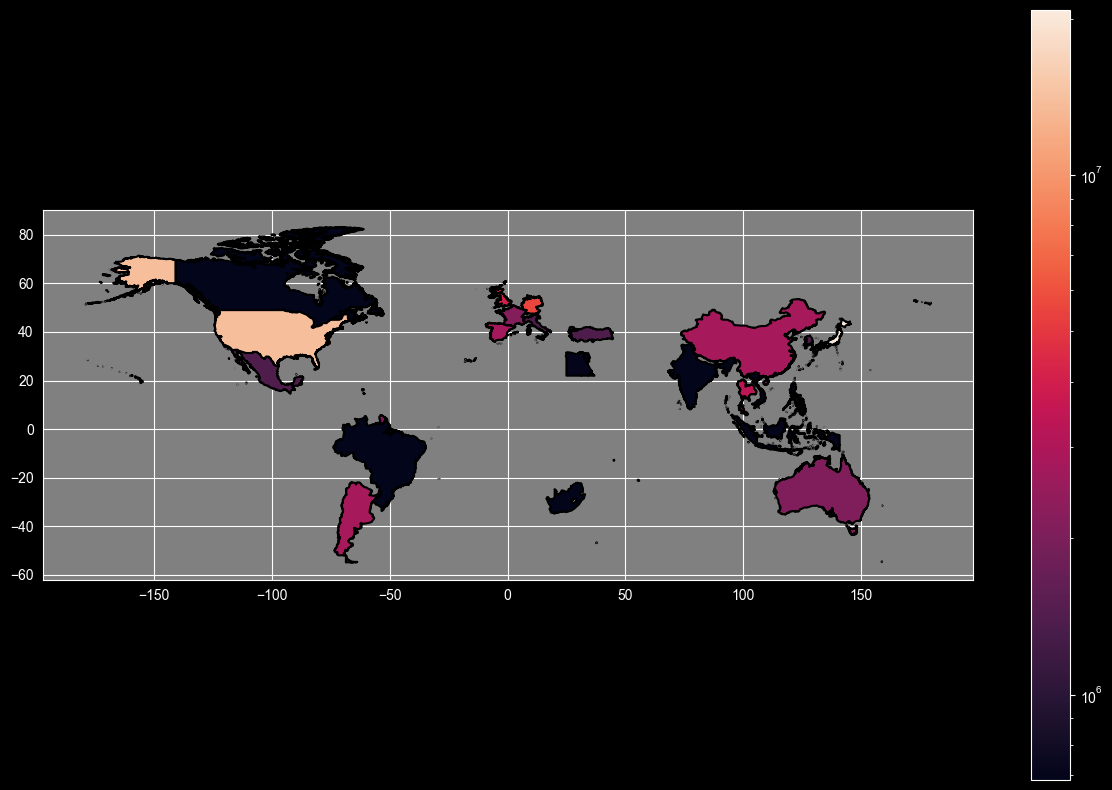

In [59]:
ax = gdfWatched.plot(figsize=(15,10),
                     linewidth=1.5,
                     edgecolor = "black",
                     column = "totalWatched",
                     legend=True,
                     norm=LogNorm()
                     )
ax.set_facecolor("gray")
plt.show()

In [57]:
dfUsersProfiles = None
dfAnime = None